# Practical 5: working with public single-cell data from the fly brain

**ISN Neurochemistry School 2026**

All cells in the fly brain carry the same genome. Cell types differ in which
genes they transcribe, and in which regions of the genome are accessible to
transcription factors. In this practical you will examine both, using data that
other laboratories have already published and deposited.

The question:

> Can a Kenyon cell be distinguished from a glial cell using published
> single-cell data, and do gene expression and chromatin accessibility give the
> same answer?

No raw sequencing data is processed here. You will download the processed
results deposited by the authors and analyse them with the standard tools:
`scanpy` for expression, `pandas` for tables, `pyBigWig` for coverage.

**Outline**

1. Gene expression in the adult brain (Fly Cell Atlas, via scanpy)
2. Differential expression to find marker genes
3. The larval brain, which still contains neural progenitors
4. Chromatin accessibility in the adult brain (Janssens et al. 2022)
5. Identification of cell-type-specific regions
6. Export of candidate enhancers for Practical 6

Everything runs on a laptop CPU.

## Running on Google Colab

Run the cell below first. On Colab it installs the software and fetches the
course files, which takes about a minute. On a laptop install it does nothing,
so run it either way.

Colab may show a **Restart session** button when the install finishes. Click it,
then run this cell once more. That is expected.

In [1]:
# Colab setup. On a laptop install this cell does nothing.
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q "crested[motif]"
    !git clone -q https://github.com/aertslab/isn-school-2026 /content/course
    %cd /content/course
    print("Ready. If a RESTART SESSION button appeared, click it and run this cell again.")
else:
    print("Running locally, nothing to install.")

Running locally, nothing to install.


## 0. Setup

Run this cell first. It locates the course folder and imports the libraries used
below. If it fails, resolve that before continuing.

In [2]:
import sys
from pathlib import Path

# Locate the course folder, independent of where Jupyter was started
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.set_figure_params(figsize=(6, 5), dpi=90, frameon=False)

print("scanpy", sc.__version__)
print("course folder:", ROOT)

scanpy 1.12.4
course folder: /Users/u0132293/Documents/software/coursework


/var/folders/64/7xv6rxvs1_n73y_yl4v80fyrrhzqcv/T/ipykernel_26763/4235232111.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


## 1. The datasets

| | Gene expression | Chromatin accessibility |
|---|---|---|
| Publication | Li, Janssens et al. 2022, *Science* 375:eabk2432 | Janssens et al. 2022, *Nature* 601:630 |
| Dataset | Fly Cell Atlas, 10x head | adult brain scATAC-seq |
| Assay | single-cell RNA-seq | single-cell ATAC-seq |
| Source | https://flycellatlas.org | https://flybrain.aertslab.org, GEO GSE163697 |

The Fly Cell Atlas is the reference single-cell atlas for *Drosophila*. It covers
the whole animal tissue by tissue; we use the head and restrict the analysis to
its brain cell types. It is worth learning because it is the resource you will
return to for your own genes.

A third dataset, the larval brain of Ravenscroft et al. 2019, is used in section
3 to look at an earlier developmental stage.

### Getting the data

The published head file is 2.5 GB, and most of that is material we do not use:
twenty stored clusterings with their marker tables, a PCA, and a
highly-variable-gene matrix that omits most genes. Reading it takes about 50
seconds and 2.5 GB of memory, and subsetting it afterwards needs more memory
than an 8 GB laptop has.

`scripts/prepare_data.py` therefore does the reduction once: it selects the
brain cells and drops the unused fields, writing a 44 MB h5ad that `scanpy`
opens in under a second. Nothing is recomputed; the counts, the UMAP coordinates
and the annotations are the authors'. Read that script if you want to see
exactly what was kept.

If the prepared files are already on your machine or on the USB stick, the next
cell does nothing.

In [3]:
from scripts.download_data import fca_head, larval_brain_loom
from scripts.prepare_data import make_fca_brain_h5ad, make_larval_h5ad

fca_head()              # 2.5 GB, downloaded once
larval_brain_loom()     # 21 MB

make_fca_brain_h5ad()   # -> data/processed/fca_brain.h5ad   (44 MB)
make_larval_h5ad()      # -> data/processed/larval_brain.h5ad (22 MB)

Fly Cell Atlas - 10x head, stringent (2.5 GB)
  Tissue list and other formats: https://flycellatlas.org
  already here: fca_head_stringent.h5ad (2644.2 MB)
Ravenscroft et al. 2019 - larval brain scRNA-seq
  already here: Ravenscroft_2019_LarvalBrain.loom (20.9 MB)
  already prepared: fca_brain.h5ad (44 MB)
  already prepared: larval_brain.h5ad


PosixPath('/Users/u0132293/Documents/software/coursework/data/processed/larval_brain.h5ad')

## 2. Gene expression

From here on this is ordinary `scanpy`. The same commands work on any h5ad file
you download in future, so they are worth reading rather than just running.

In [4]:
adata = sc.read_h5ad(ROOT / "data" / "processed" / "fca_brain.h5ad")
adata

AnnData object with n_obs × n_vars = 30789 × 13056
    obs: 'annotation', 'annotation_broad', 'annotation_broad_extrapolated', 'sex', 'n_genes'
    var: 'is_TF'
    uns: 'source'
    obsm: 'X_tsne', 'X_umap'
    layers: None (.X)

The printed summary is the structure of an `AnnData` object, which is how
`scanpy` holds a dataset:

- `n_obs x n_vars` is cells by genes
- `obs` holds per-cell information, including the cell type annotation
- `var` holds per-gene information, here a flag for transcription factors
- `obsm` holds per-cell coordinates, here the UMAP the atlas authors computed

You can look at any of these as a normal pandas table.

In [5]:
adata.obs["annotation"].value_counts().head(10)

annotation
ensheathing glial cell                         1855
adult brain perineurial glial cell             1640
columnar neuron T1                             1618
T neuron T4/T5a-b                              1525
lamina monopolar neuron L2                     1238
gamma Kenyon cell                              1139
lamina monopolar neuron L3                     1047
medullary intrinsic neuron Mi1                 1001
adult lamina epithelial/marginal glial cell     984
transmedullary neuron Tm1                       957
Name: count, dtype: int64

### Has this data already been normalised?

Cells differ in how many transcripts were captured, so expression values are
normally scaled to a common total per cell and then log transformed. In scanpy
that is `sc.pp.normalize_total` followed by `sc.pp.log1p`.

Applying it twice distorts the data, so the first question about any file you did
not process yourself is whether it has been done already. A downloaded file will
rarely tell you. Two checks answer it.

In [6]:
values = adata.X.data          # the non-zero entries

print("largest value:", values.max().round(2))
print("are all values whole numbers?",
      np.allclose(values[:5000], np.round(values[:5000])))

# If the matrix is log1p of a normalised matrix, then undoing the log should
# give the same total in every cell.
first_cells = adata.X[:200].toarray()
print("per-cell totals after undoing the log:",
      np.expm1(first_cells).sum(axis=1).round(1)[:5])

largest value: 8.31
are all values whole numbers? False
per-cell totals after undoing the log: [10000. 10000. 10000. 10000. 10000.]


The values are not whole numbers, the largest is about 8, and undoing the log
gives exactly 10,000 in every cell. This file has already been through
`normalize_total(target_sum=1e4)` and `log1p`.

So we do **not** normalise it. Raw counts would look quite different: whole
numbers, a much larger maximum, and a different total in every cell. You will see
exactly that in section 4, where the larval file does need normalising.

This matters in practice. Running `sc.pp.normalize_total` on already normalised
data is a silent error: nothing raises, the plots still appear, and the numbers
are wrong.

### Two levels of annotation

The atlas annotates cells at two levels, and both are columns in `obs`:

- `annotation_broad`, the coarse class. We selected on it when building this
  file, so within the brain it has two values, neuron and glial cell
- `annotation`, the cell type, with 62 values here

Start with the coarse one. `sc.pl.umap` draws the coordinates stored in
`obsm["X_umap"]`.

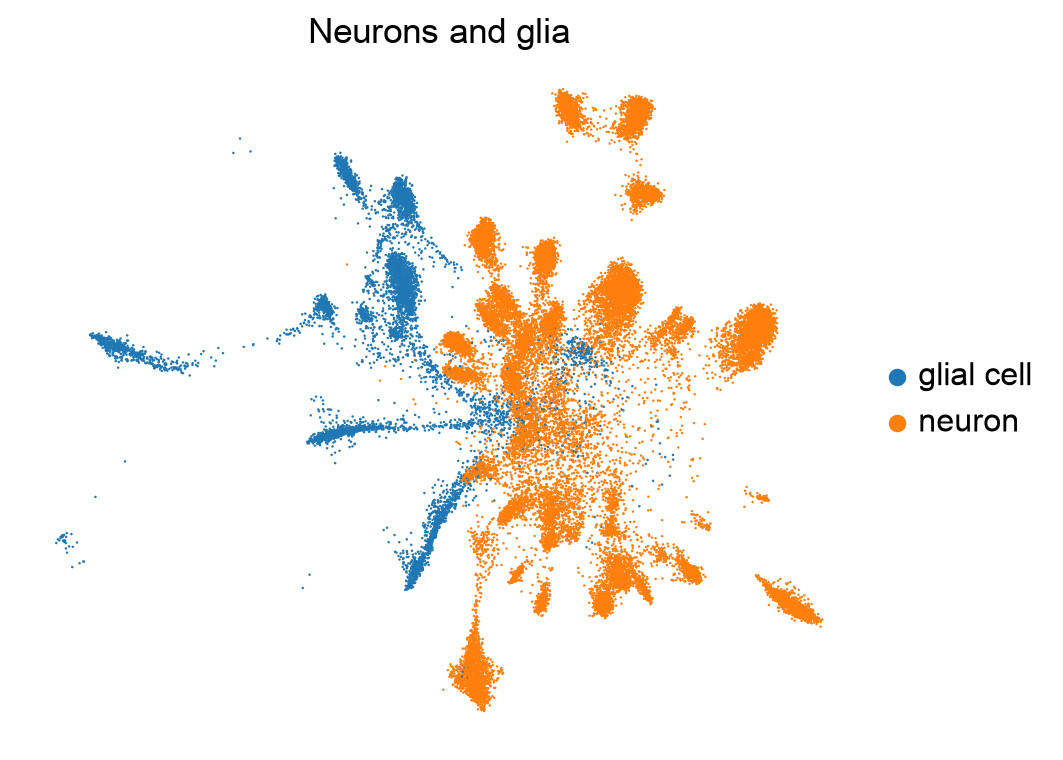

In [7]:
sc.pl.umap(adata, color="annotation_broad", title="Neurons and glia", frameon=False)

The glial cells form a small number of groups away from the main mass of
neurons. This is the split that section 5 looks for in the chromatin.

Now the same map at cell type resolution. Placing the legend on the plot rather
than beside it is the usual way to show an atlas with this many categories.

The figure is large; zoom in to read it.

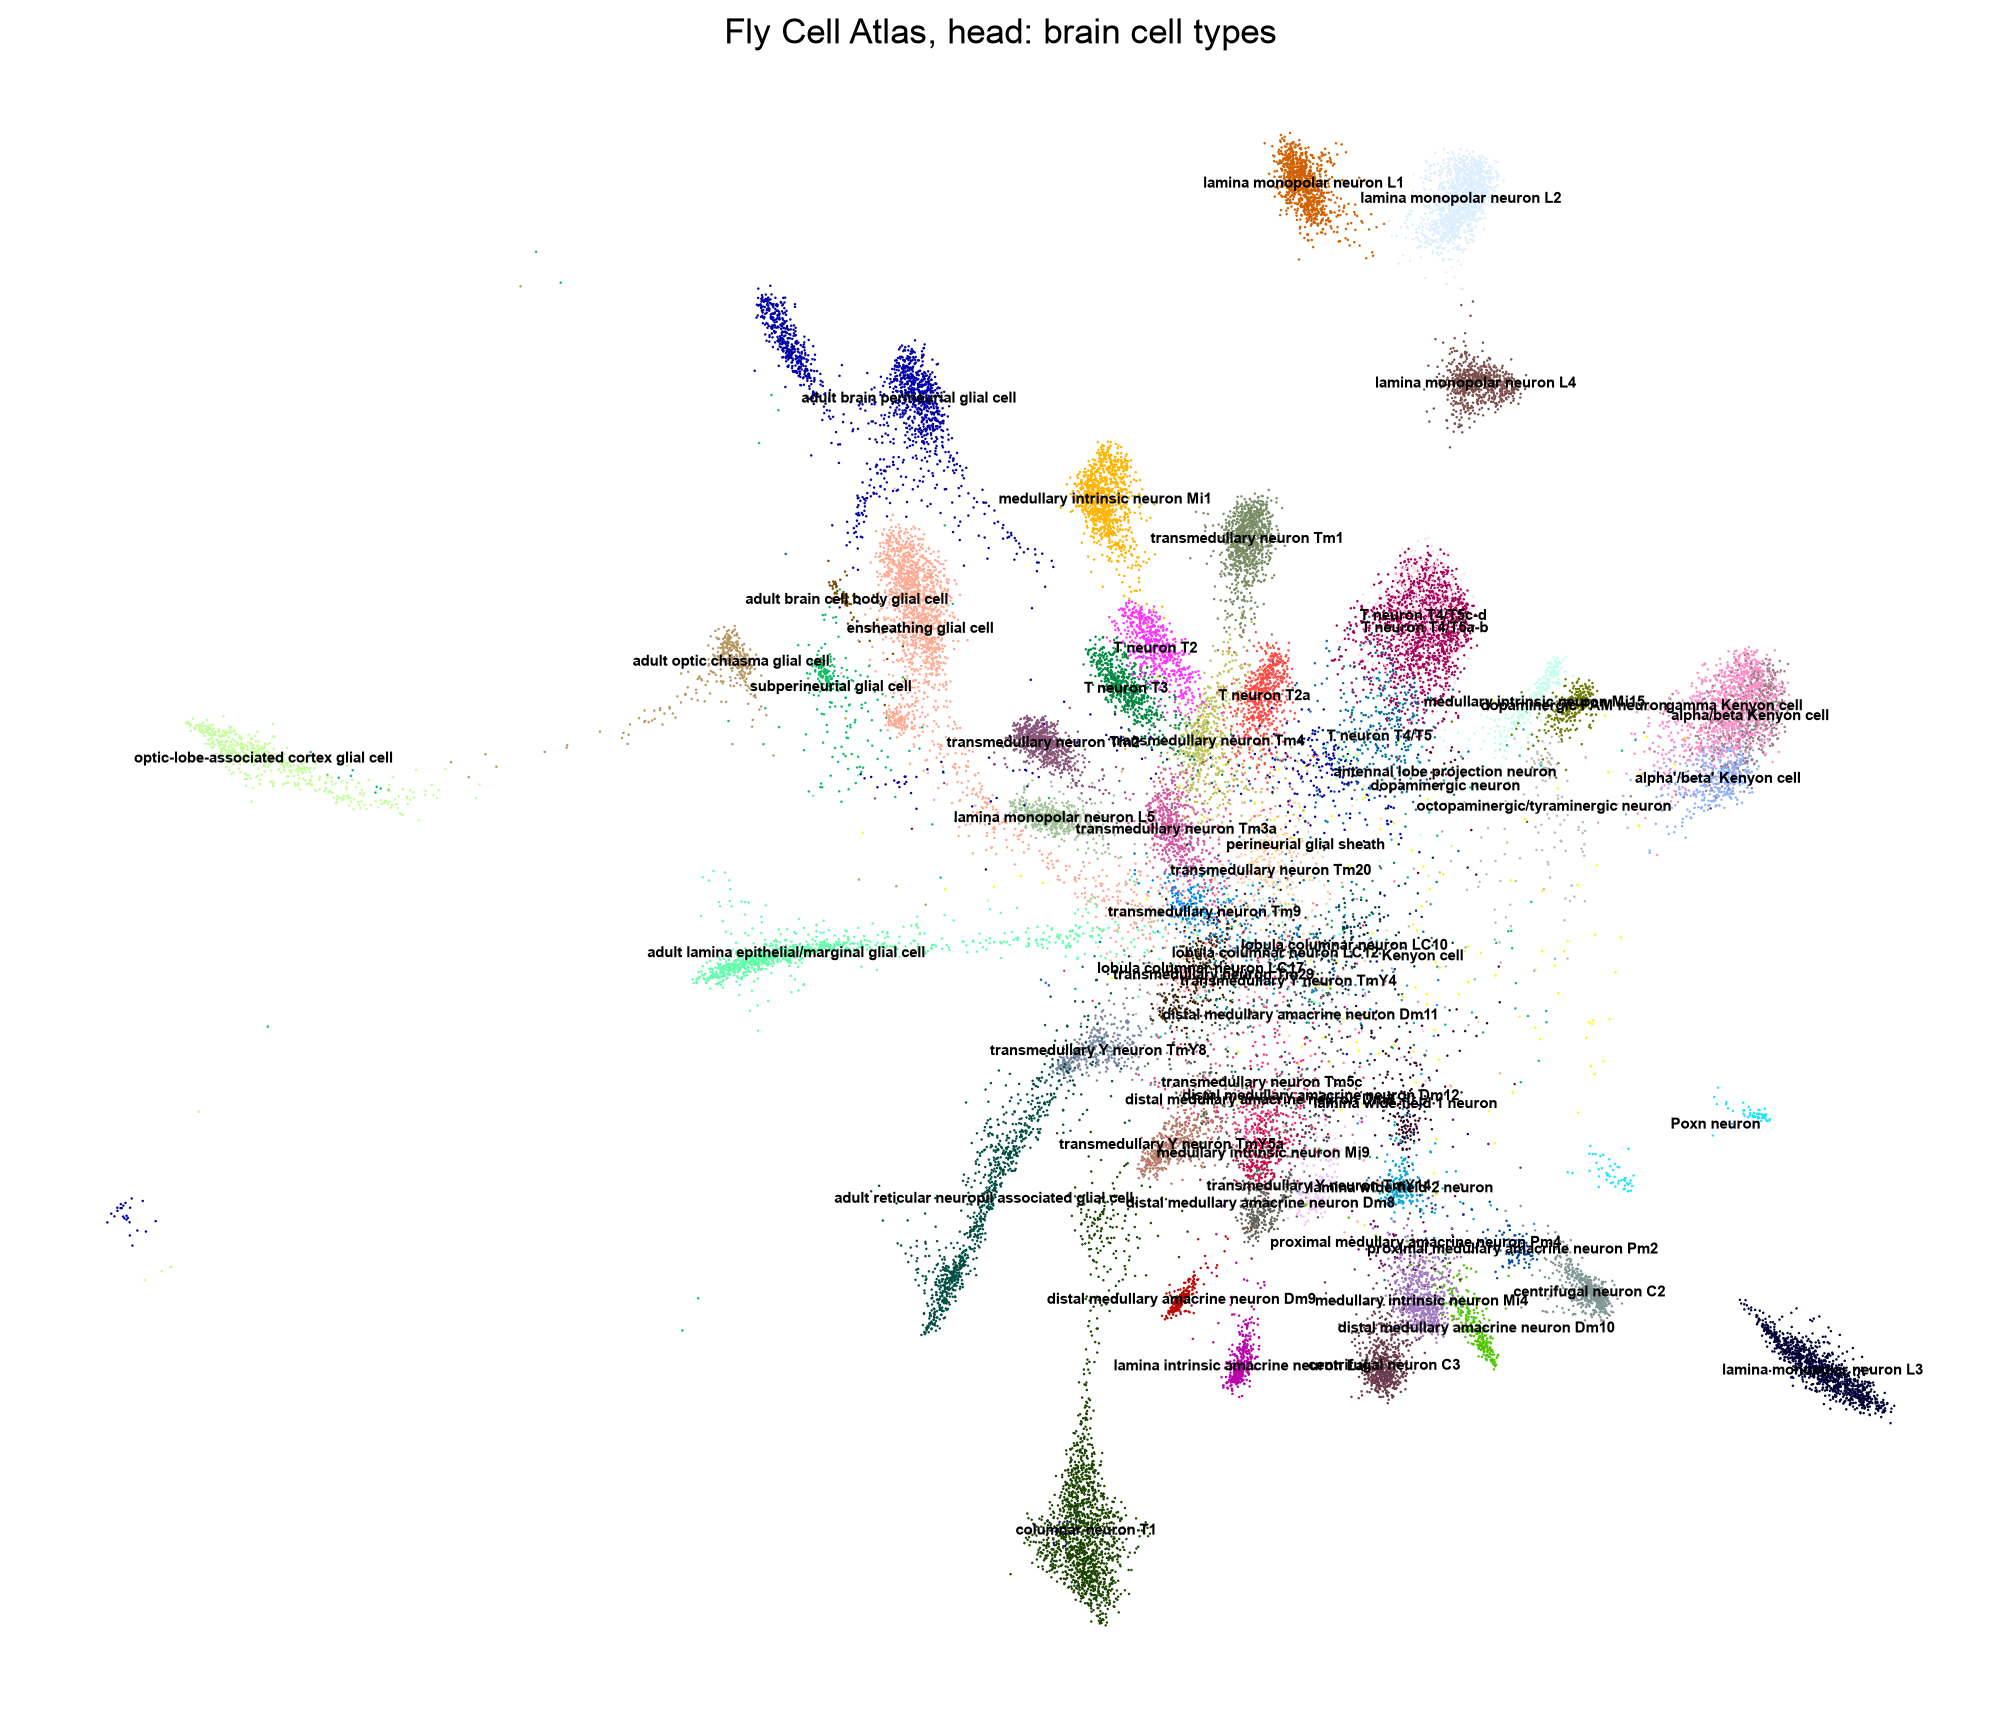

In [8]:
# 62 cell type labels need a bigger canvas than the default. `plt.rc_context`
# changes the figure size for this plot only.
with plt.rc_context({"figure.figsize": (14, 12)}):
    sc.pl.umap(
        adata,
        color="annotation",
        legend_loc="on data",
        legend_fontsize=6,
        title="Fly Cell Atlas, head: brain cell types",
        frameon=False,
    )

Points to note:

- Cell types carry full ontology names, so the map can be read without a key
- Optic lobe neuron types (T, Tm, Mi, Dm, L) dominate by number, which reflects
  the size of the optic lobes
- Glial types form their own groups, separate from all neurons
- The Kenyon cell types sit together

### The four cell types used in this practical

These are the types for which we also have ATAC data. The two datasets name them
differently, so `scripts/celltypes.py` holds the mapping.

In [9]:
from scripts.celltypes import ATAC_TO_RNA

CELL_TYPES = ["KC_g", "KC_ab", "T1", "Astrocyte_like"]
our_types = [ATAC_TO_RNA[ct] for ct in CELL_TYPES]

for atac, rna in ATAC_TO_RNA.items():
    print(f"{atac:20s} -> {rna}")

KC_g                 -> gamma Kenyon cell
KC_ab                -> alpha/beta Kenyon cell
KC_abPrime           -> alpha'/beta' Kenyon cell
T1                   -> columnar neuron T1
T2                   -> T neuron T2
T2a                  -> T neuron T2a
T3                   -> T neuron T3
Astrocyte_like       -> adult reticular neuropil associated glial cell
Ensheathing_glia     -> ensheathing glial cell
Cortex_glia          -> optic-lobe-associated cortex glial cell
Perineurial_glia     -> adult brain perineurial glial cell
Subperineurial_glia  -> subperineurial glial cell
Chiasm_glia          -> adult optic chiasma glial cell


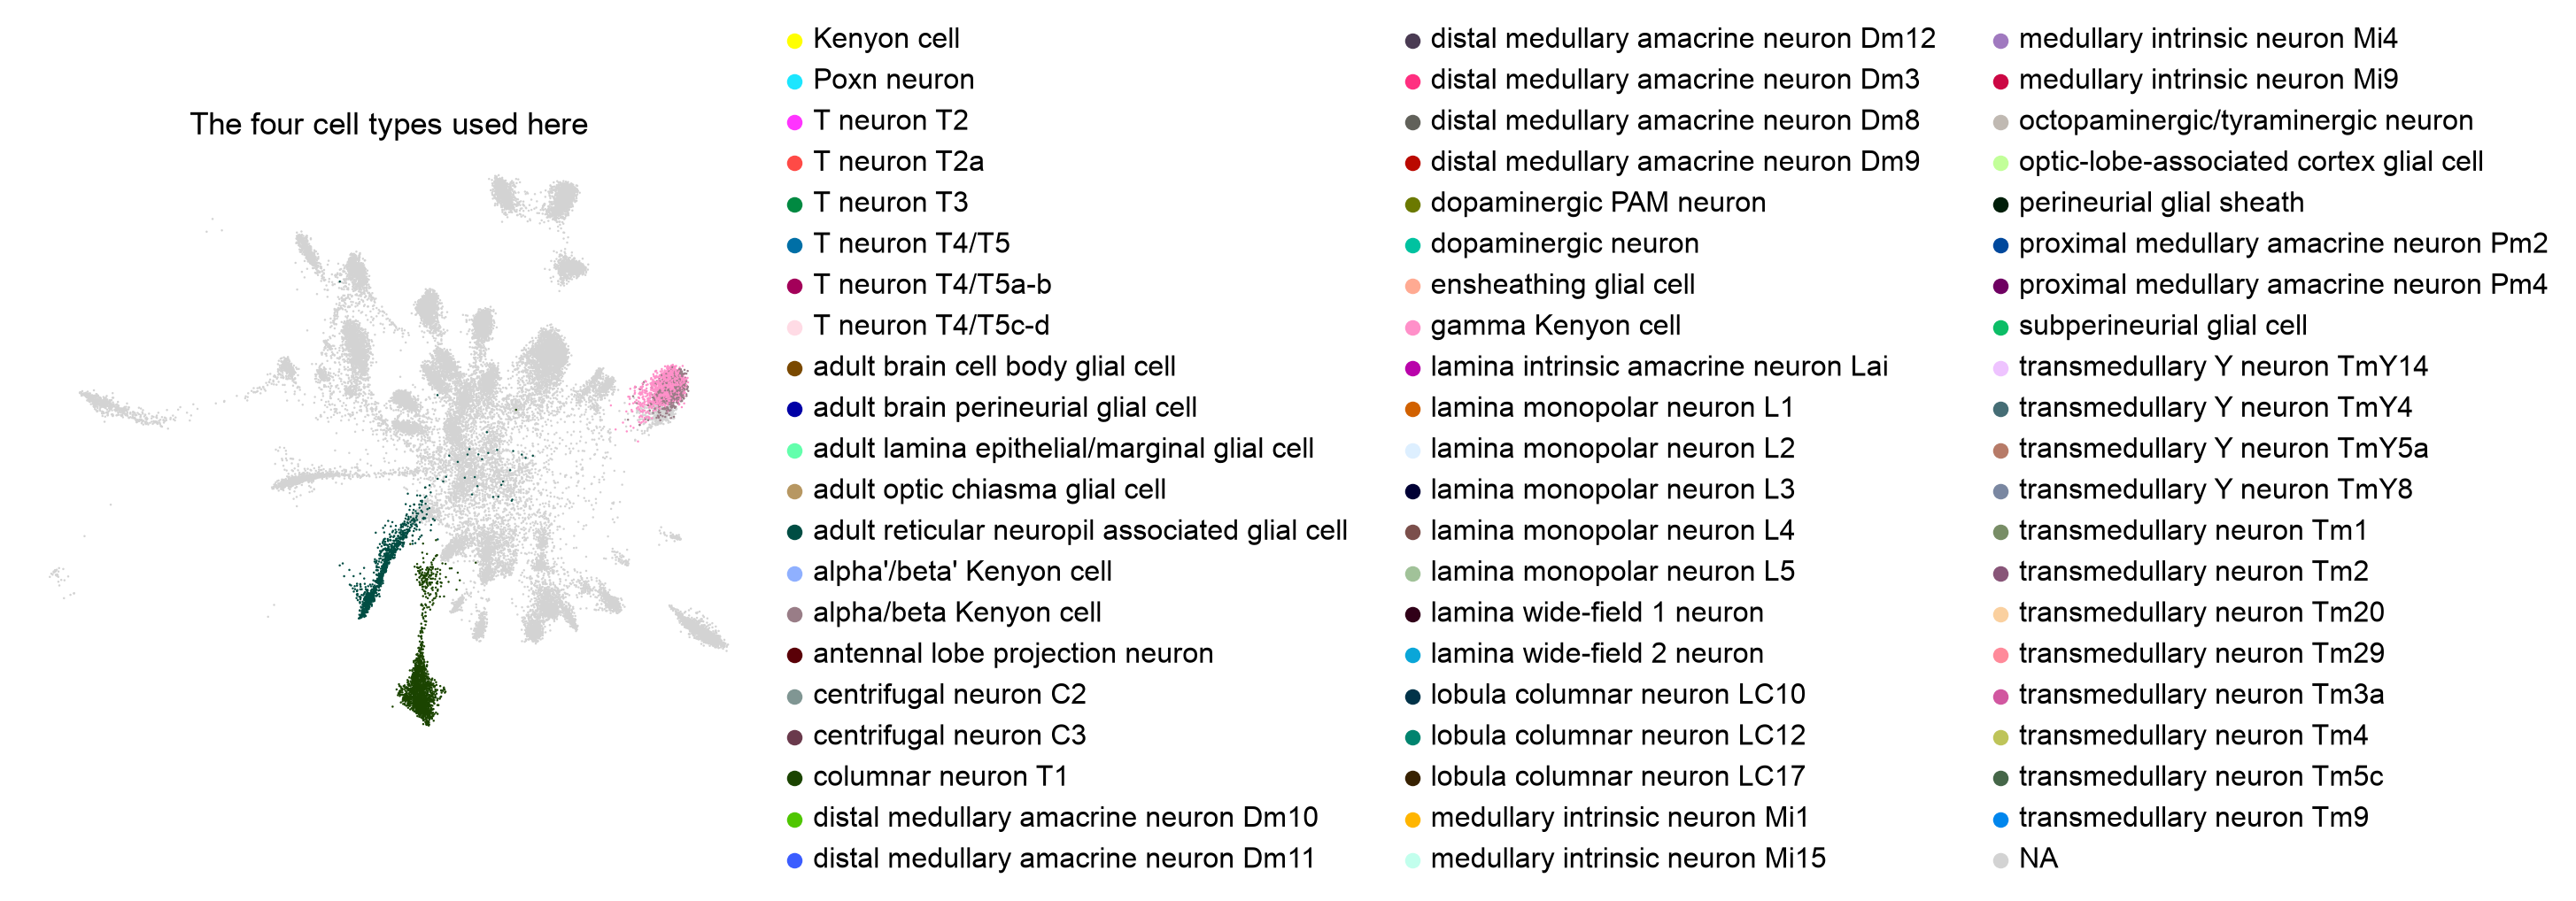

In [10]:
# A column that is the cell type name for our four types and NaN elsewhere,
# which makes scanpy grey out everything else.
adata.obs["focus"] = adata.obs["annotation"].where(
    adata.obs["annotation"].isin(our_types)
)

sc.pl.umap(adata, color="focus", title="The four cell types used here", frameon=False)

### Expression of a marker gene

`repo` encodes a transcription factor required for glial differentiation, and is
expressed in glia but not in neurons.

Before running the next cell: which populations should show signal?

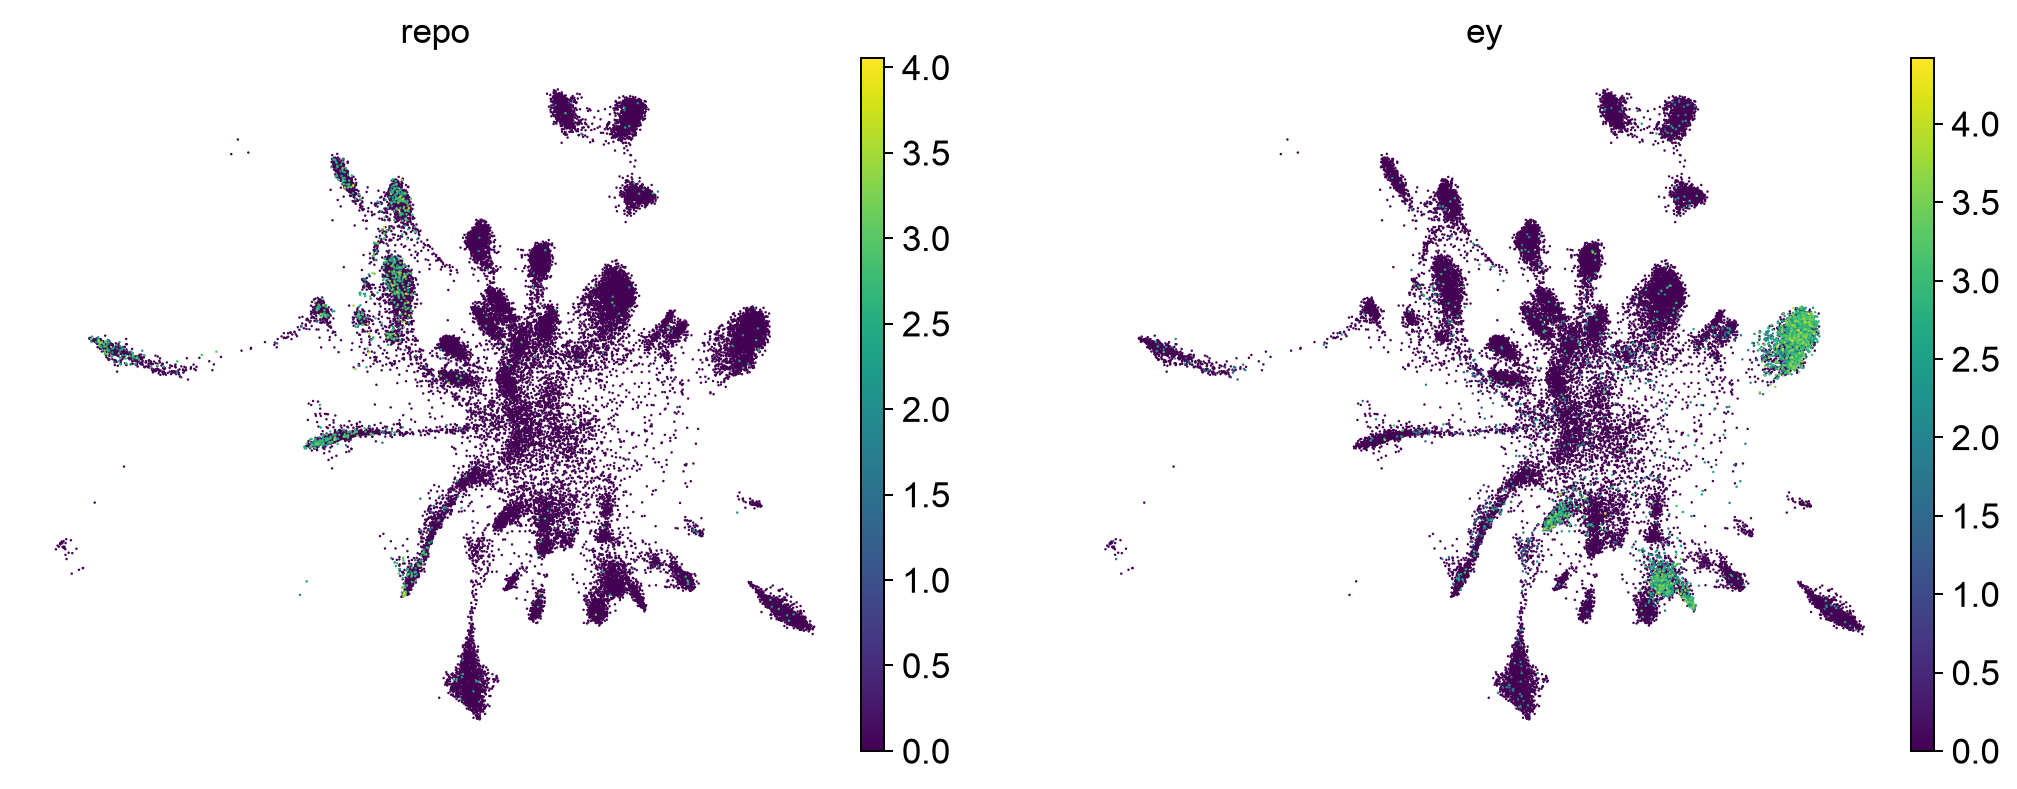

In [11]:
sc.pl.umap(adata, color=["repo", "ey"], frameon=False, ncols=2)

`repo` is restricted to the glial groups. `ey` (*eyeless*, a Pax6 homologue) is
concentrated in the Kenyon cells.

### The numbers behind the picture

A projection is not a measurement. `sc.get.obs_df` pulls expression values into a
pandas table, which can then be grouped by cell type.

In [12]:
values = sc.get.obs_df(adata, keys=["repo", "ey", "alrm", "annotation"])
means = values.groupby("annotation", observed=True).mean()

means.sort_values("repo", ascending=False).head(6).round(2)

,repo,ey,alrm
annotation,,,
subperineurial glial cell,0.40,0.04,0.02
optic-lobe-associated cortex glial cell,0.39,0.10,0.01
adult lamina epithelial/marginal glial cell,0.31,0.08,0.02
adult optic chiasma glial cell,0.31,0.02,0.03
ensheathing glial cell,0.28,0.07,0.04
adult brain perineurial glial cell,0.28,0.05,0.01


The highest cell types for `repo` are all glial. `alrm`, an astrocyte marker,
should be far more restricted; compare the two columns.

In [13]:
means.sort_values("alrm", ascending=False).head(6).round(2)

,repo,ey,alrm
annotation,,,
adult reticular neuropil associated glial cell,0.22,0.15,0.95
lobula columnar neuron LC12,0.00,0.17,0.05
lamina intrinsic amacrine neuron Lai,0.02,0.02,0.04
ensheathing glial cell,0.28,0.07,0.04
medullary intrinsic neuron Mi15,0.01,0.05,0.04
medullary intrinsic neuron Mi9,0.02,0.12,0.04


### A dot plot across the four cell types

`sc.pl.dotplot` is the usual way to show several genes across several cell types
at once. Colour is mean expression, dot size is the fraction of cells in which
the gene was detected.

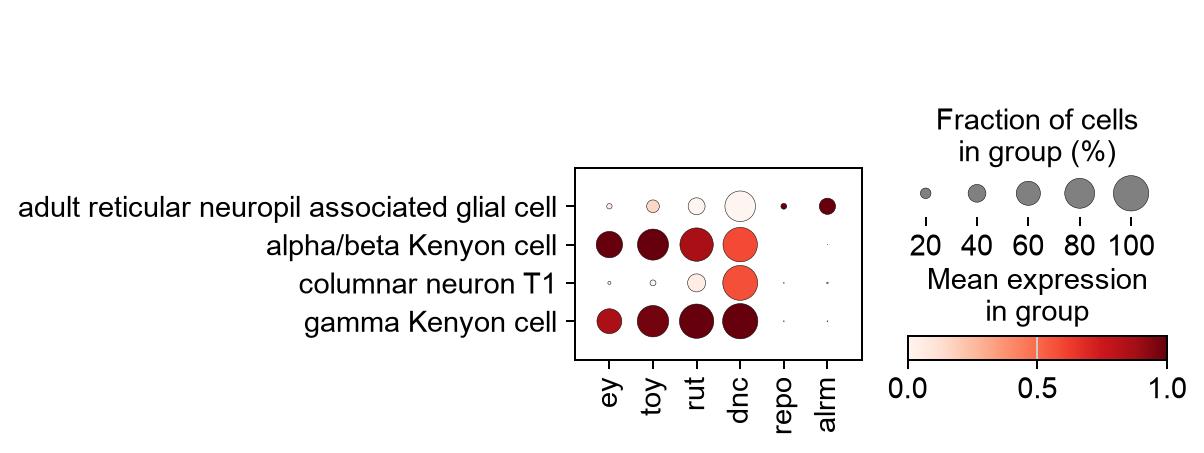

In [14]:
sc.pl.dotplot(
    adata[adata.obs["annotation"].isin(our_types)],
    var_names=["ey", "toy", "rut", "dnc", "repo", "alrm"],
    groupby="annotation",
    standard_scale="var",
)

## 3. Finding marker genes rather than assuming them

So far we started from genes already known to mark a cell type. The standard
approach when you do not know them is a differential expression test: for each
gene, compare its expression in one cell type against all others.

`sc.tl.rank_genes_groups` does this. The Wilcoxon rank-sum test is the usual
choice for single-cell data because it makes no assumption about the shape of
the distribution. It takes about 15 seconds here.

In [15]:
sc.tl.rank_genes_groups(
    adata,
    groupby="annotation",
    groups=["gamma Kenyon cell"],
    reference="rest",
    method="wilcoxon",
)

markers = sc.get.rank_genes_groups_df(adata, group="gamma Kenyon cell")
markers.head(12).round(3)

,names,scores,logfoldchanges,pvals,pvals_adj
0,rad,51.997002,5.669,0.0,0.0
1,mub,51.297001,3.298,0.0,0.0
2,Rgk1,51.129002,5.143,0.0,0.0
3,rut,49.076000,4.340,0.0,0.0
4,Pka-R2,46.139000,3.877,0.0,0.0
5,Dop1R2,44.771000,5.552,0.0,0.0
6,Pka-C1,44.316002,3.324,0.0,0.0
7,sNPF,44.007000,5.083,0.0,0.0
8,dnc,42.896999,2.391,0.0,0.0
9,CG32204,42.437000,4.900,0.0,0.0


`scores` is the test statistic, `logfoldchanges` the effect size, and
`pvals_adj` the p-value after correction for multiple testing.

Several of these are recognisable. `rut` (*rutabaga*, an adenylyl cyclase) and
`dnc` (*dunce*, a phosphodiesterase) are the two classical *Drosophila* learning
mutants, and `Pka-C1`, `Pka-R2` and `Dop1R2` are further components of the same
cAMP signalling pathway. The mushroom body is the site of associative learning in
the fly, so recovering this pathway from an unsupervised test is a useful check
that the annotation and the method are behaving.

### Which of them are transcription factors?

For Practical 6 the transcription factors matter, because they are the proteins
that bind DNA and could explain why a region is accessible. The atlas carries
FlyBase's classification in `var`.

In [16]:
tf_names = adata.var_names[adata.var["is_TF"]]
print(f"{len(tf_names)} of {adata.n_vars} genes are annotated transcription factors")

markers[markers["names"].isin(tf_names)].head(10).round(3)

595 of 13056 genes are annotated transcription factors


,names,scores,logfoldchanges,pvals,pvals_adj
11,toy,41.964001,4.477,0.0,0.0
13,pros,41.216000,4.241,0.0,0.0
16,fru,38.120998,2.979,0.0,0.0
24,mamo,34.993000,2.217,0.0,0.0
33,ey,32.304001,4.553,0.0,0.0
40,dac,28.108000,3.544,0.0,0.0
61,ab,23.249001,2.185,0.0,0.0
75,Mef2,20.778999,1.892,0.0,0.0
78,dati,20.231001,3.110,0.0,0.0
120,sr,16.205000,2.307,0.0,0.0


`ey` and `toy` (*twin of eyeless*) are paralogous Pax6 transcription factors,
both of which appear, alongside `dac`, `mamo`, `pros` and `fru`. These are
candidate regulators of the Kenyon cell state.

This is a testable prediction. If these transcription factors drive Kenyon cell
identity, their binding motifs should be enriched in regions accessible
specifically in Kenyon cells. Practical 6 asks a sequence model whether that is
so.

### Your turn

Change the cell type and compare the lists. Use a name from `our_types`, or any
value in `adata.obs["annotation"]`.

In [17]:
MY_CELL_TYPE = "adult reticular neuropil associated glial cell"   # change this

sc.tl.rank_genes_groups(
    adata, groupby="annotation", groups=[MY_CELL_TYPE],
    reference="rest", method="wilcoxon", key_added="my_markers",
)

my_markers = sc.get.rank_genes_groups_df(adata, group=MY_CELL_TYPE, key="my_markers")
my_markers[my_markers["names"].isin(tf_names)].head(10).round(3)

,names,scores,logfoldchanges,pvals,pvals_adj
15,zfh2,30.500000,3.167,0.0,0.0
16,hth,30.402000,2.773,0.0,0.0
26,pnt,25.177999,3.823,0.0,0.0
28,pdm3,25.003000,2.785,0.0,0.0
30,ct,24.113001,2.250,0.0,0.0
41,CG42741,20.777000,7.606,0.0,0.0
43,pros,20.472000,2.392,0.0,0.0
50,Glut4EF,18.305000,0.786,0.0,0.0
54,ab,17.573999,1.762,0.0,0.0
69,Pdp1,15.211000,1.102,0.0,0.0


The glial list is led by `zfh2`, `hth` and `pnt`. Of its ten entries only two,
`pros` and `ab`, also appear in the Kenyon cell list, so the two cell types are
characterised by largely different transcription factors, as expected for
unrelated cell types. `pnt` (*pointed*) is required for glial differentiation.

`pros` (*prospero*) appearing in both is not an error. It is a transcription
factor used in more than one context in the nervous system, and a gene can
contribute to several cell identities.

`repo` does not appear, although section 2 showed it is glial. This is not a
contradiction. The test compares one cell type against all others, and the other
glial types also express `repo`, so it does not distinguish this astrocyte
population from them. What counts as a marker depends entirely on the comparison
being made.

## 4. An earlier stage: the larval brain

The Fly Cell Atlas samples adult flies, whose brains contain differentiated
neurons and glia but no dividing neural progenitors. The larval brain does.

Ravenscroft et al. 2019 profiled 5,056 larval brain cells. The file is annotated
with progenitor types that have no adult counterpart:

- **NB**, neuroblasts, the neural stem cells
- **GMC**, ganglion mother cells, the dividing intermediate progeny of a neuroblast
- prefixes `OL` and `CB` distinguish optic lobe from central brain

Clusters the authors left as bare numbers were never annotated, so we keep only
the named ones.

In [18]:
larval = sc.read_h5ad(ROOT / "data" / "processed" / "larval_brain.h5ad")
larval = larval[larval.obs["is_annotated"]].copy()

# The same two checks as in section 2, on a different file.
print("largest value:", larval.X.data.max())
print("are all values whole numbers?",
      np.allclose(larval.X.data[:5000], np.round(larval.X.data[:5000])))
print("per-cell totals:", np.asarray(larval.X.sum(axis=1)).ravel()[:5].astype(int))

largest value: 13701
are all values whole numbers? True
per-cell totals: [ 5759 25230 17168 12335  4146]


Whole numbers, a maximum in the thousands, and a different total in every cell.
These are raw counts, so this file does need normalising.

In [19]:
sc.pp.normalize_total(larval, target_sum=1e4)
sc.pp.log1p(larval)

print(larval.shape)
larval.obs["annotation"].value_counts().head(8)

(1202, 9853)


annotation
OL GMC          255
OL Type I NB    147
CB GMC          133
Hey+ Neurons    105
SUR             105
Type II NB      103
Lamina           88
ENS              71
Name: count, dtype: int64

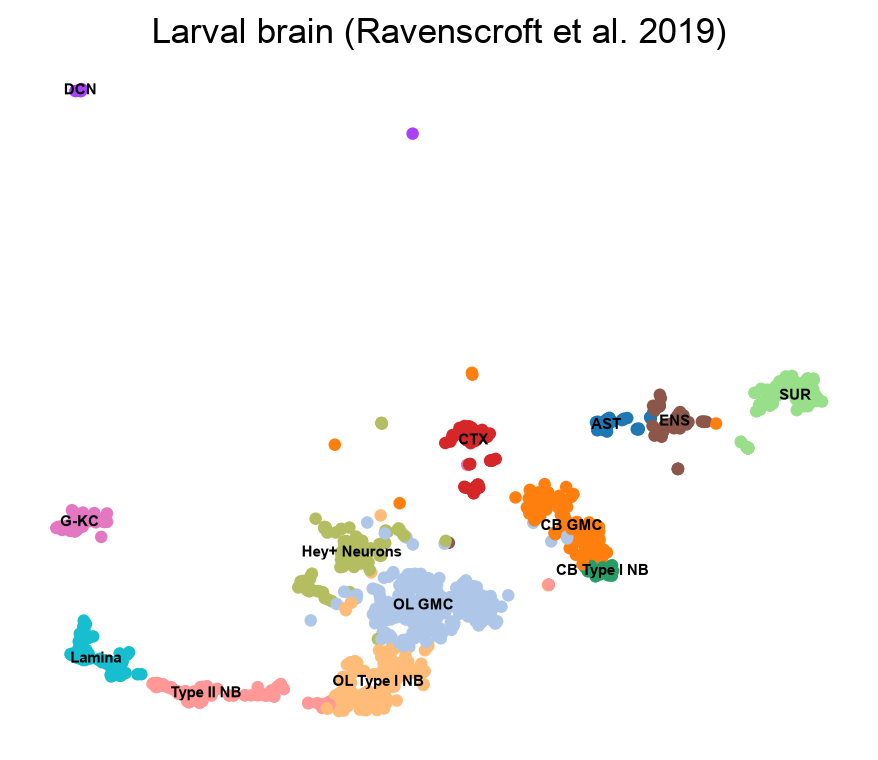

In [20]:
sc.pl.umap(larval, color="annotation", legend_loc="on data", legend_fontsize=6,
           title="Larval brain (Ravenscroft et al. 2019)", frameon=False)

`dpn` (*deadpan*) is a transcription factor expressed in neuroblasts and switched
off as they differentiate. `elav` is conventionally described as a pan-neuronal
marker. Compare them.

In [21]:
larval_values = sc.get.obs_df(larval, keys=["dpn", "elav", "annotation"])
comparison = larval_values.groupby("annotation", observed=True).mean()

comparison.sort_values("dpn", ascending=False).round(2)

,dpn,elav
annotation,,
OL Type I NB,1.40,1.59
CB Type I NB,0.72,1.19
Type II NB,0.47,0.61
OL GMC,0.26,2.60
Lamina,0.20,1.69
Hey+ Neurons,0.07,2.70
CB GMC,0.07,2.36
G-KC,0.05,1.85
CTX,0.04,0.47


This table repays careful reading, because it is not a clean mirror image.

- `dpn` is restricted to the three neuroblast populations and falls sharply
  elsewhere
- `elav` is high in neurons (`Hey+ Neurons`, `DCN`, `G-KC`) and low in the glial
  types (`CTX`, `AST`, `ENS`, `SUR`), so it does separate neurons from glia
- `elav` is also high in both ganglion mother cell populations and is detected in
  optic lobe neuroblasts, so it does **not** separate progenitors from
  differentiated neurons

This is the same lesson as `repo` above. A marker gene is defined by the
comparison you make with it.

This stage comparison is the basis of project 2: the regulatory landscape changes
between larval and adult stages, and both expression and accessibility data exist
for the two stages.

## 5. Chromatin accessibility

Expression tells us which genes are transcribed, not which regulatory regions are
responsible. ATAC-seq measures which regions of the genome are accessible, and
accessible regions are where transcription factors can bind.

We now use the Janssens et al. ATAC data for the same four adult cell types, and
ask whether regions near `repo` and `ey` are accessible in the cell types that
express them.

Two file types are available per cell type:

- **peaks** (`.bed`), the regions called accessible, about 0.4 MB each
- **coverage tracks** (`.bigwig`), signal at every position, about 58 MB each

The next cell prints each URL before downloading. Files already present are
skipped.

> Offline fallback: run
> `import os; os.environ["ISN_USB"] = "/Volumes/ISN2026"` (Windows: `"E:\\"`)
> before the cell, and files are copied from the USB stick.

In [22]:
from scripts.download_data import janssens_adult_peaks, janssens_adult_bigwigs

peak_files = janssens_adult_peaks(CELL_TYPES)
bigwig_files = janssens_adult_bigwigs(CELL_TYPES)

Janssens et al. 2022 - adult brain peaks per cell type
  already here: KC_g.bed (0.4 MB)
  already here: KC_ab.bed (0.4 MB)
  already here: T1.bed (0.3 MB)
  already here: Astrocyte_like.bed (0.3 MB)
Janssens et al. 2022 - adult brain scATAC bigwigs
  already here: KC_g.bw (57.8 MB)
  already here: KC_ab.bw (61.5 MB)
  already here: T1.bw (28.0 MB)
  already here: Astrocyte_like.bw (41.2 MB)


### Peak files

A peak file is a BED file: one row per accessible region, giving chromosome,
start and end. It is a plain text table, so pandas reads it directly.

In [23]:
kc_peaks = pd.read_csv(
    peak_files["KC_g"], sep="\t", header=None,
    names=["chrom", "start", "end"], usecols=[0, 1, 2],
)
kc_peaks["width"] = kc_peaks["end"] - kc_peaks["start"]

print(f"gamma Kenyon cells: {len(kc_peaks):,} accessible regions")
print(f"median width: {kc_peaks['width'].median():,.0f} bp")
kc_peaks.head()

gamma Kenyon cells: 17,931 accessible regions
median width: 306 bp


,chrom,start,end,width
0,chr2L,5493,6026,533
1,chr2L,34684,35218,534
2,chr2L,66414,67324,910
3,chr2L,72087,72927,840
4,chr2L,73036,73702,666


The median width is a few hundred base pairs, the size range reported for
*Drosophila* enhancers.

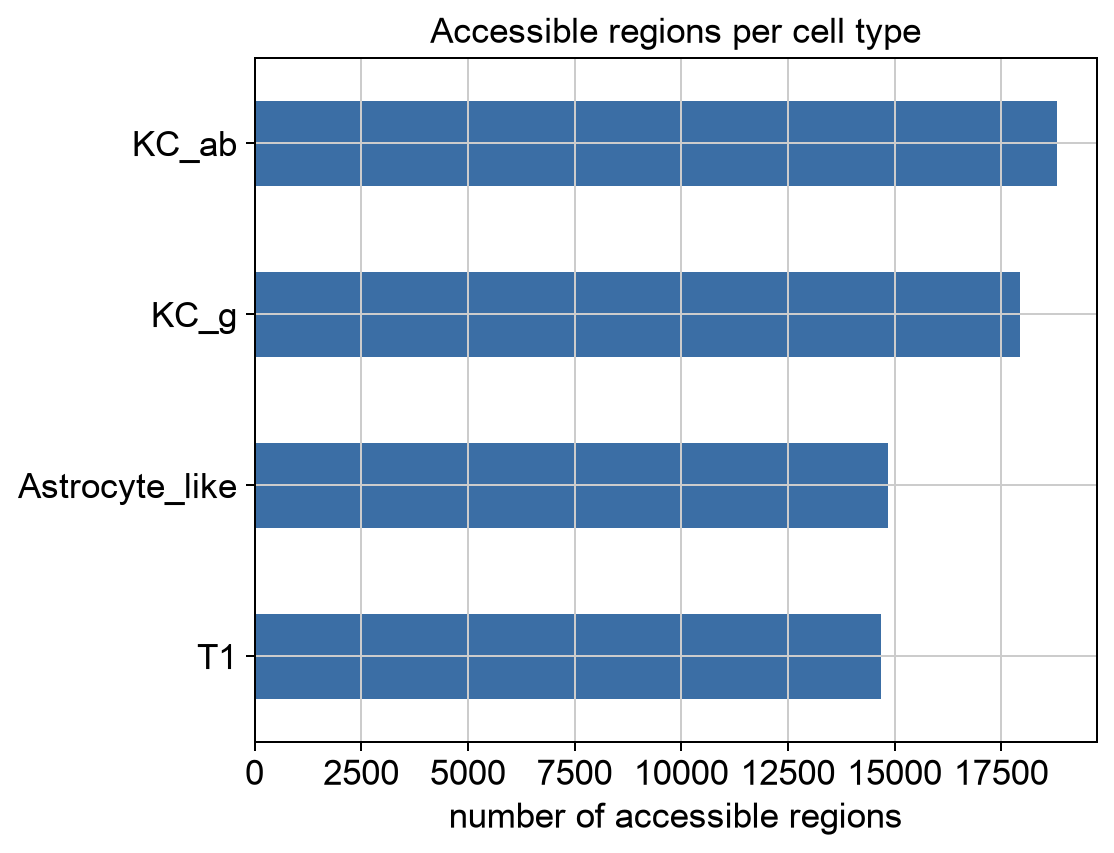

KC_g              17931
KC_ab             18803
T1                14691
Astrocyte_like    14846
dtype: int64

In [24]:
counts = pd.Series({name: sum(1 for _ in open(path)) for name, path in peak_files.items()})

counts.sort_values().plot.barh(color="#3b6ea5")
plt.xlabel("number of accessible regions")
plt.title("Accessible regions per cell type")
plt.show()

counts

The four cell types have comparable numbers of accessible regions, within about
30% of each other. Cell identity is not reflected in the total amount of
accessible chromatin, but in its location.

### Reading a coverage track

A peak call is a binary summary. The bigwig holds the signal itself.
`pyBigWig` is the standard reader. Opening a file and asking for the mean signal
in a window looks like this:

In [25]:
import pyBigWig

with pyBigWig.open(str(bigwig_files["KC_g"])) as bw:
    print("chromosomes:", dict(list(bw.chroms().items())[:4]))
    # mean signal in 5 equal bins across a 2 kb window of the ey locus
    print("signal:", bw.stats("chr4", 712500, 714500, nBins=5, type="mean"))

chromosomes: {'chr2L': 23513712, 'chr2R': 25286936, 'chr3L': 28110227, 'chr3R': 32079331}
signal: [4.282286344528199, 22.895416557312014, 12.510866641998291, 3.494459163665772, 5.619308128356933]


Drawing a whole locus means doing that in many small bins for each cell type and
plotting the result. `scripts/plots.py` wraps exactly that loop, plus the gene
models underneath; open it if you want to see the `pyBigWig` calls it makes.

`repo` was expressed in glia in section 2. The prediction is that regions around
`repo` are accessible in `Astrocyte_like` and not in the three neuronal types.

/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


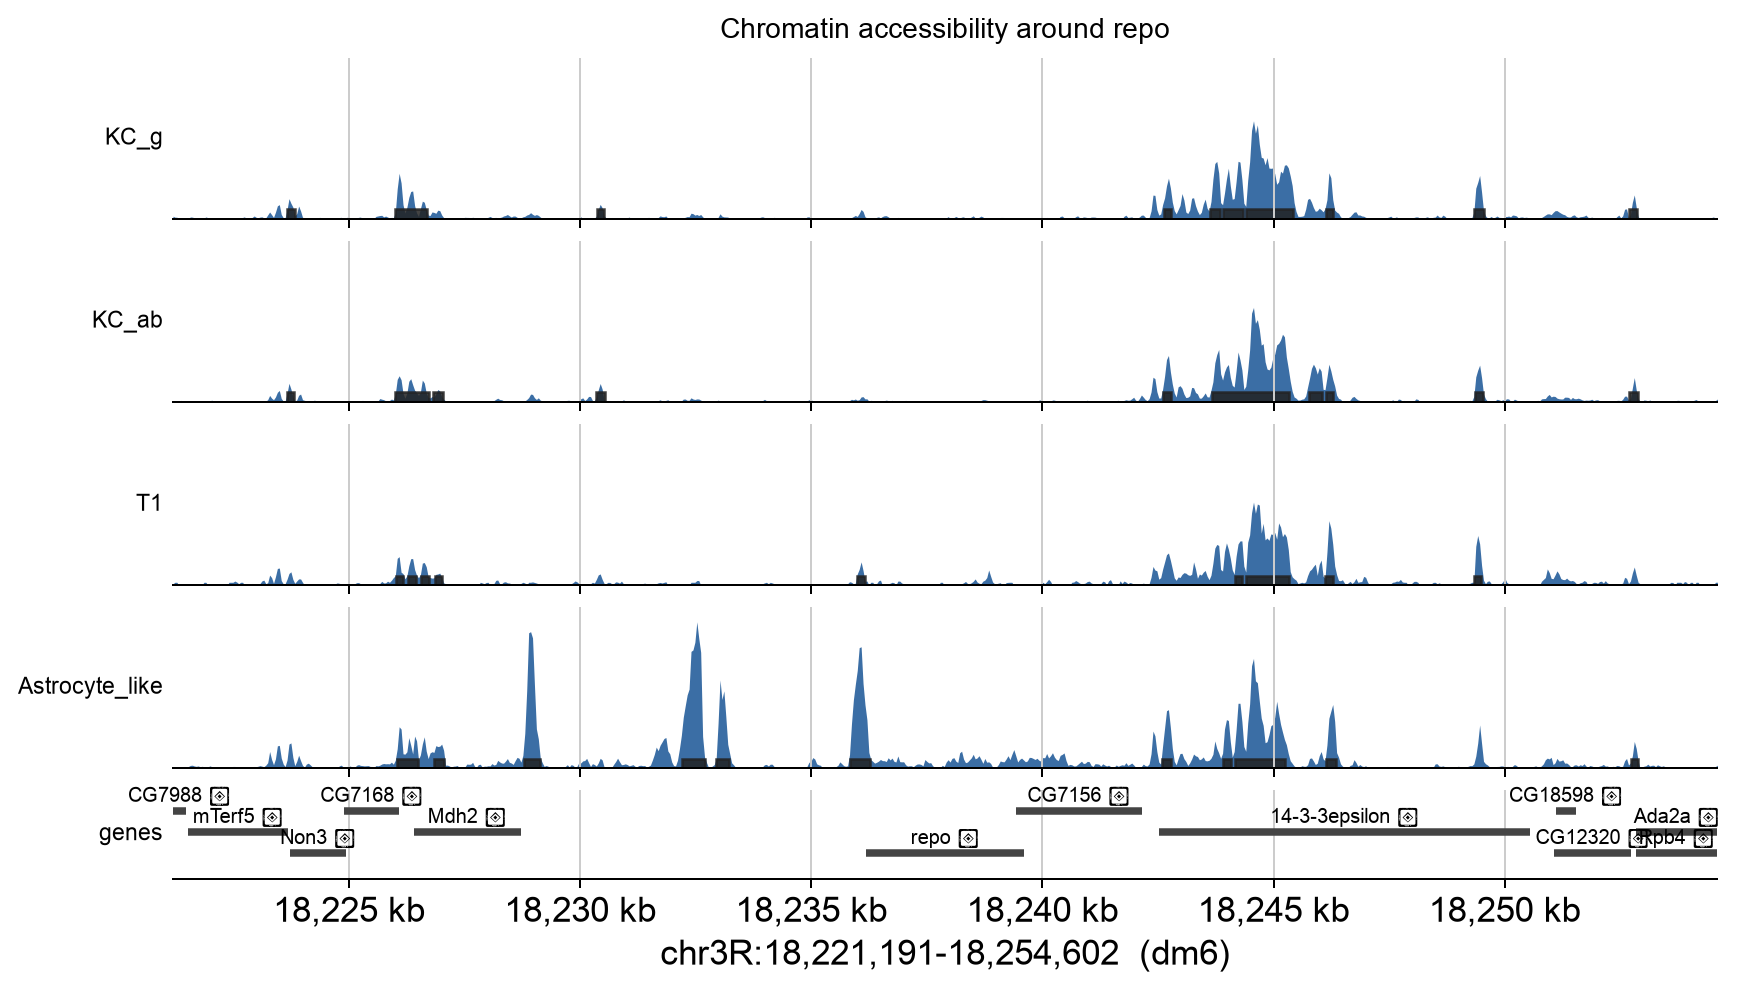

In [26]:
from scripts.plots import plot_tracks

plot_tracks(bigwig_files, gene="repo", flank=15_000, peaks=peak_files)
plt.show()

Reading the figure:

- one row per cell type, on a common y-axis so heights are comparable
- the filled blue profile is ATAC signal
- black bars at the base of each row are the called peaks
- the lower panel shows genes in the window, with the arrow indicating strand

Several regions upstream of `repo` carry signal in `Astrocyte_like` and little or
none in the neuronal types. This is the accessibility counterpart of the
expression pattern in section 2.

One peak near the right of the window is present in all four cell types. Regions
accessible in every cell type are generally promoters of broadly expressed genes
rather than cell-type-specific enhancers.

/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


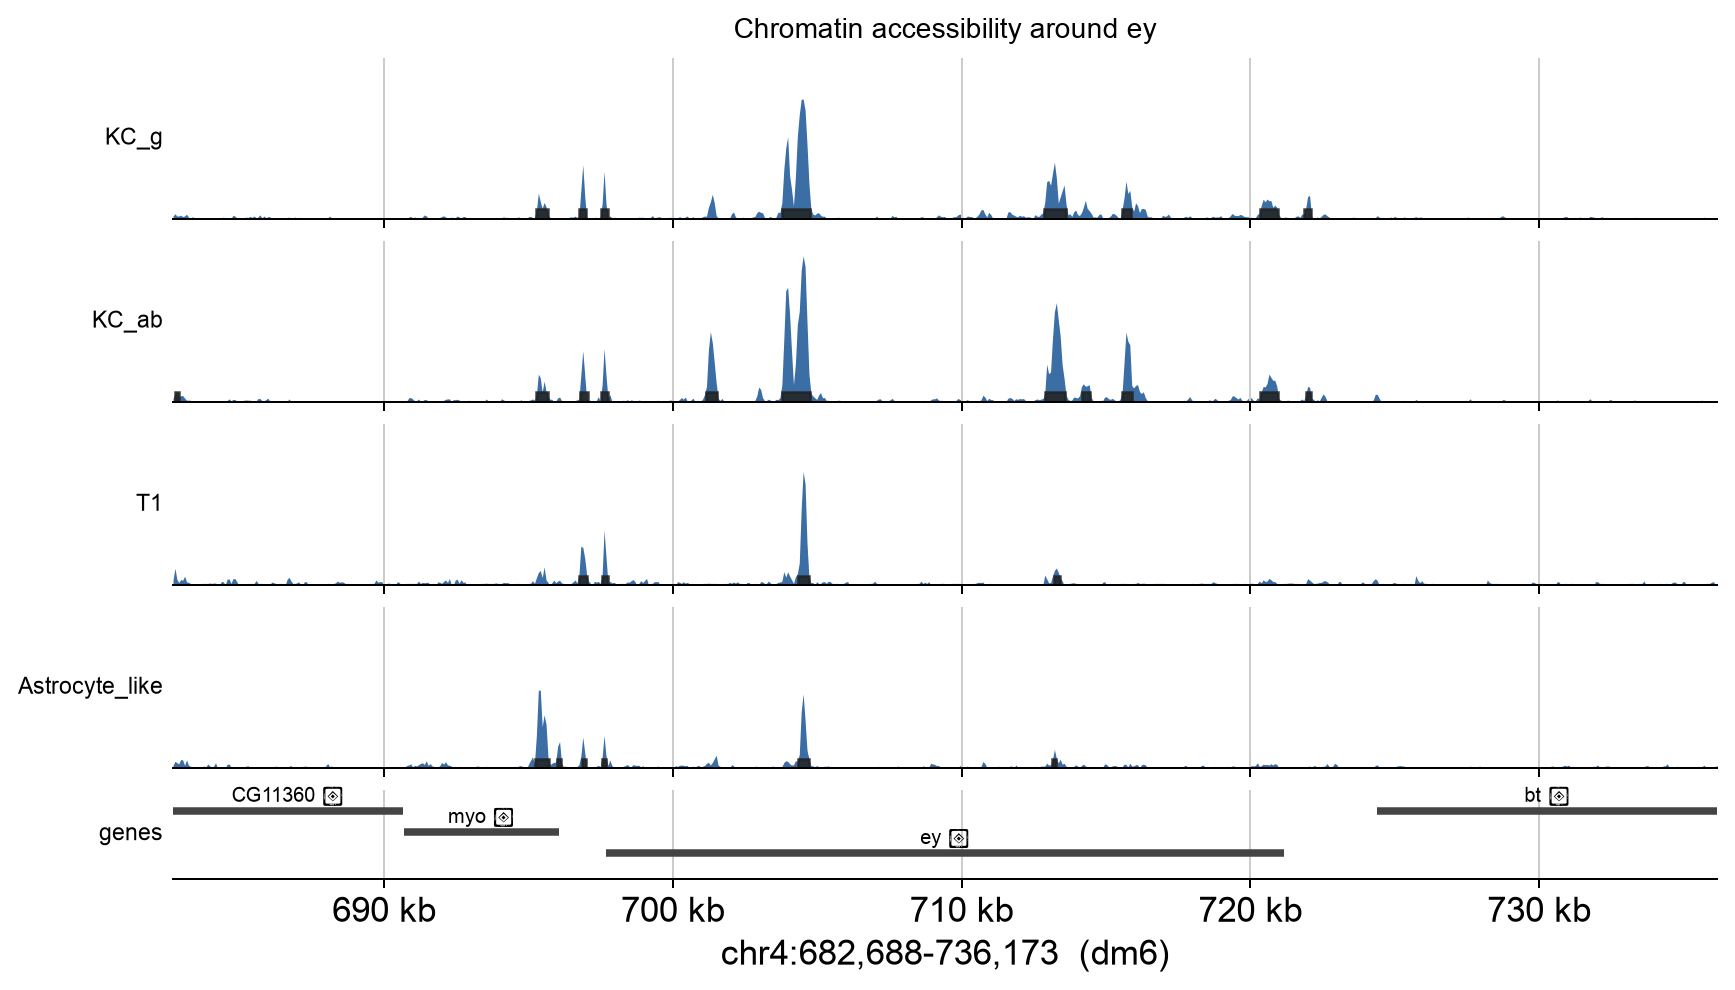

In [27]:
plot_tracks(bigwig_files, gene="ey", flank=15_000, peaks=peak_files)
plt.show()

Within the `ey` locus the peaks near 713 kb are higher in `KC_g` and `KC_ab` than
in `T1` or `Astrocyte_like`. This region is intronic rather than
promoter-proximal, which is typical: enhancers are frequently in introns,
downstream of the gene, or tens of kilobases away.

### Your turn

Pick a gene and compare its expression with its accessibility. Gene symbols are
case-sensitive and not uniformly lower case: FlyBase capitalises symbols first
identified through a dominant allele or named by homology, so it is `alrm` and
`elav` but `Imp` and `Eaat1`.

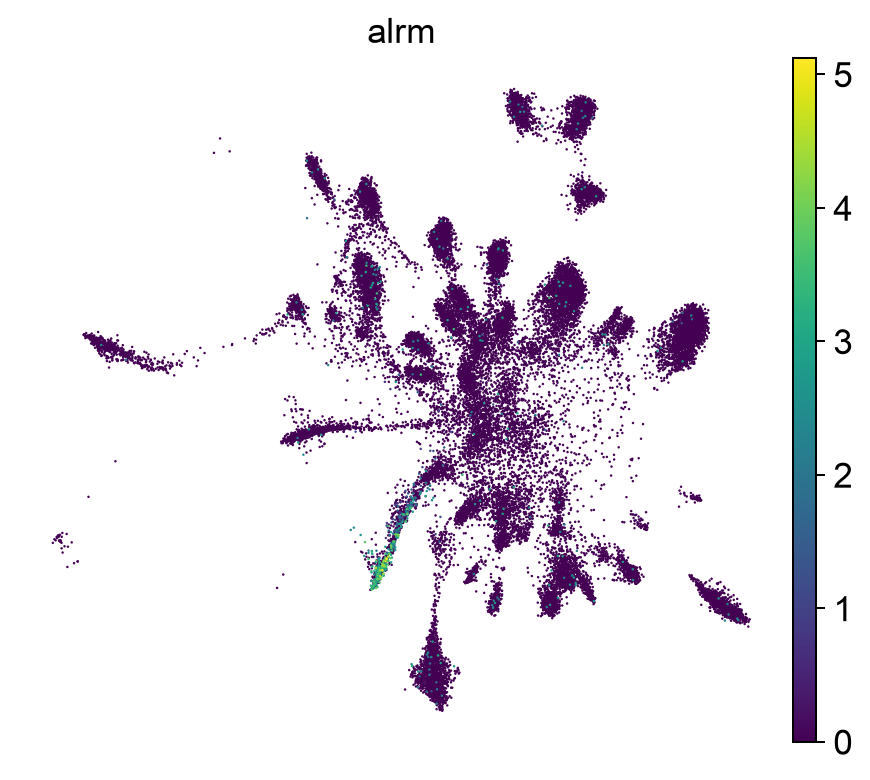

/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


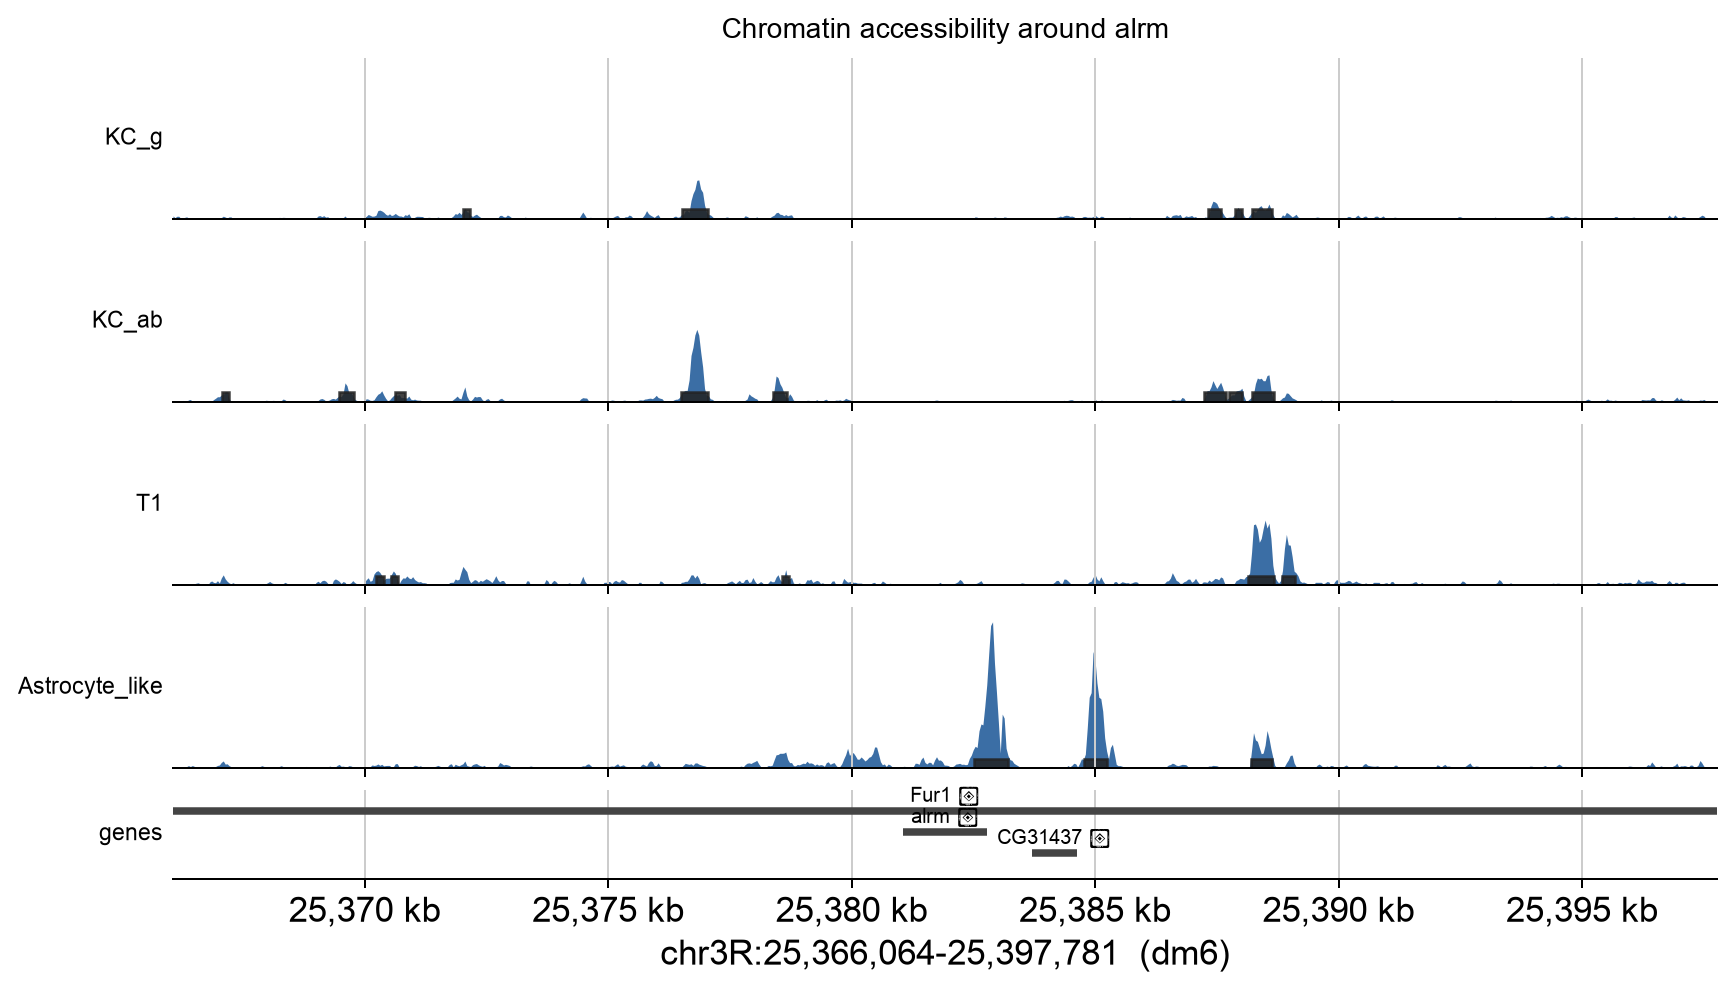

In [28]:
MY_GENE = "alrm"      # change this, then re-run the cell

sc.pl.umap(adata, color=MY_GENE, frameon=False)
plot_tracks(bigwig_files, gene=MY_GENE, flank=15_000, peaks=peak_files)
plt.show()

For each gene, record whether the cell type with the highest expression is also
the one with the strongest accessibility signal. Cases where the two disagree are
informative: a region can be accessible without the nearby gene being
transcribed.

## 6. Identifying cell-type-specific regions

So far the starting point was a known gene. The alternative is to find regions
that differ between cell types first, and identify the nearby genes afterwards.

The comparison below finds gamma Kenyon cell peaks that do not overlap any peak
in `T1` or `Astrocyte_like`, restricted to chromosome 4 to keep it quick.

In [29]:
def load_peaks(path):
    return pd.read_csv(path, sep="\t", header=None,
                       names=["chrom", "start", "end"], usecols=[0, 1, 2])

def overlaps_any(row, other):
    same = other[other["chrom"] == row["chrom"]]
    return ((same["start"] < row["end"]) & (same["end"] > row["start"])).any()

kc = load_peaks(peak_files["KC_g"])
others = pd.concat([load_peaks(peak_files[c]) for c in ["T1", "Astrocyte_like"]])

kc_chr4 = kc[kc["chrom"] == "chr4"].copy()
kc_chr4["specific"] = ~kc_chr4.apply(overlaps_any, other=others, axis=1)

specific = kc_chr4[kc_chr4["specific"]]
print(f"{len(specific)} of {len(kc_chr4)} gamma Kenyon cell peaks on chr4 "
      f"are not accessible in T1 or astrocytes")
specific.head(10)

30 of 141 gamma Kenyon cell peaks on chr4 are not accessible in T1 or astrocytes


,chrom,start,end,specific
14491,chr4,104075,104418,True
14492,chr4,111809,111955,True
14502,chr4,207112,207314,True
14506,chr4,275888,276040,True
14511,chr4,313386,313564,True
14519,chr4,395619,395906,True
14525,chr4,418832,419012,True
14528,chr4,426154,426350,True
14529,chr4,426775,427491,True
14530,chr4,437584,437990,True


In [30]:
from scripts.genes import genes_in_window

for _, r in specific.head(5).iterrows():
    near = genes_in_window(r["chrom"], r["start"] - 10_000, r["end"] + 10_000)
    names = ", ".join(near.index[:4]) if len(near) else "no gene within 10 kb"
    print(f"{r['chrom']}:{r['start']:,}-{r['end']:,}   nearby: {names}")

chr4:104,075-104,418   nearby: pan
chr4:111,809-111,955   nearby: pan, Ank
chr4:207,112-207,314   nearby: CG31998, Crk, CG31999
chr4:275,888-276,040   nearby: NfI, lncRNA:CR44023, Syt7
chr4:313,386-313,564   nearby: Syt7, Rad23, Zip102B, CG32850


Proximity is not evidence of regulation. It identifies candidates, which would
require experimental testing to confirm.

## 7. Candidate regions for Practical 6

Select two or three regions with a clear cell-type-specific pattern. In Practical
6 these sequences are given to DeepFlyBrain, a convolutional network trained on
this ATAC data, to ask which transcription factor motifs it uses to classify
them.

Two worked examples are filled in, one per cell type. Both were found by the
peak comparison above: they are called accessible in the target cell type and in
neither of the other two.

Both are exactly 500 bp long, because that is the input size DeepFlyBrain
expects. When you add your own region, centre it on the peak and take 500 bp.

The first sits at `Rgk1`, which section 3 found to be one of the strongest
gamma Kenyon cell marker genes. A cell-type-specific accessible region beside a
cell-type-specific gene is exactly the pattern we have been looking for.

In [31]:
MY_REGIONS = [
    ("chr2R", 19346269, 19346769, "near Rgk1, Kenyon cell specific"),
    ("chr3R", 18232201, 18232701, "near repo, astrocyte specific"),
]

out = ROOT / "data" / "processed" / "practical5_candidate_regions.bed"
out.parent.mkdir(parents=True, exist_ok=True)
with open(out, "w") as fh:
    for chrom, start, end, note in MY_REGIONS:
        fh.write(f"{chrom}\t{start}\t{end}\t{note}\n")

print(f"Wrote {len(MY_REGIONS)} regions to {out}")

Wrote 2 regions to /Users/u0132293/Documents/software/coursework/data/processed/practical5_candidate_regions.bed


/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


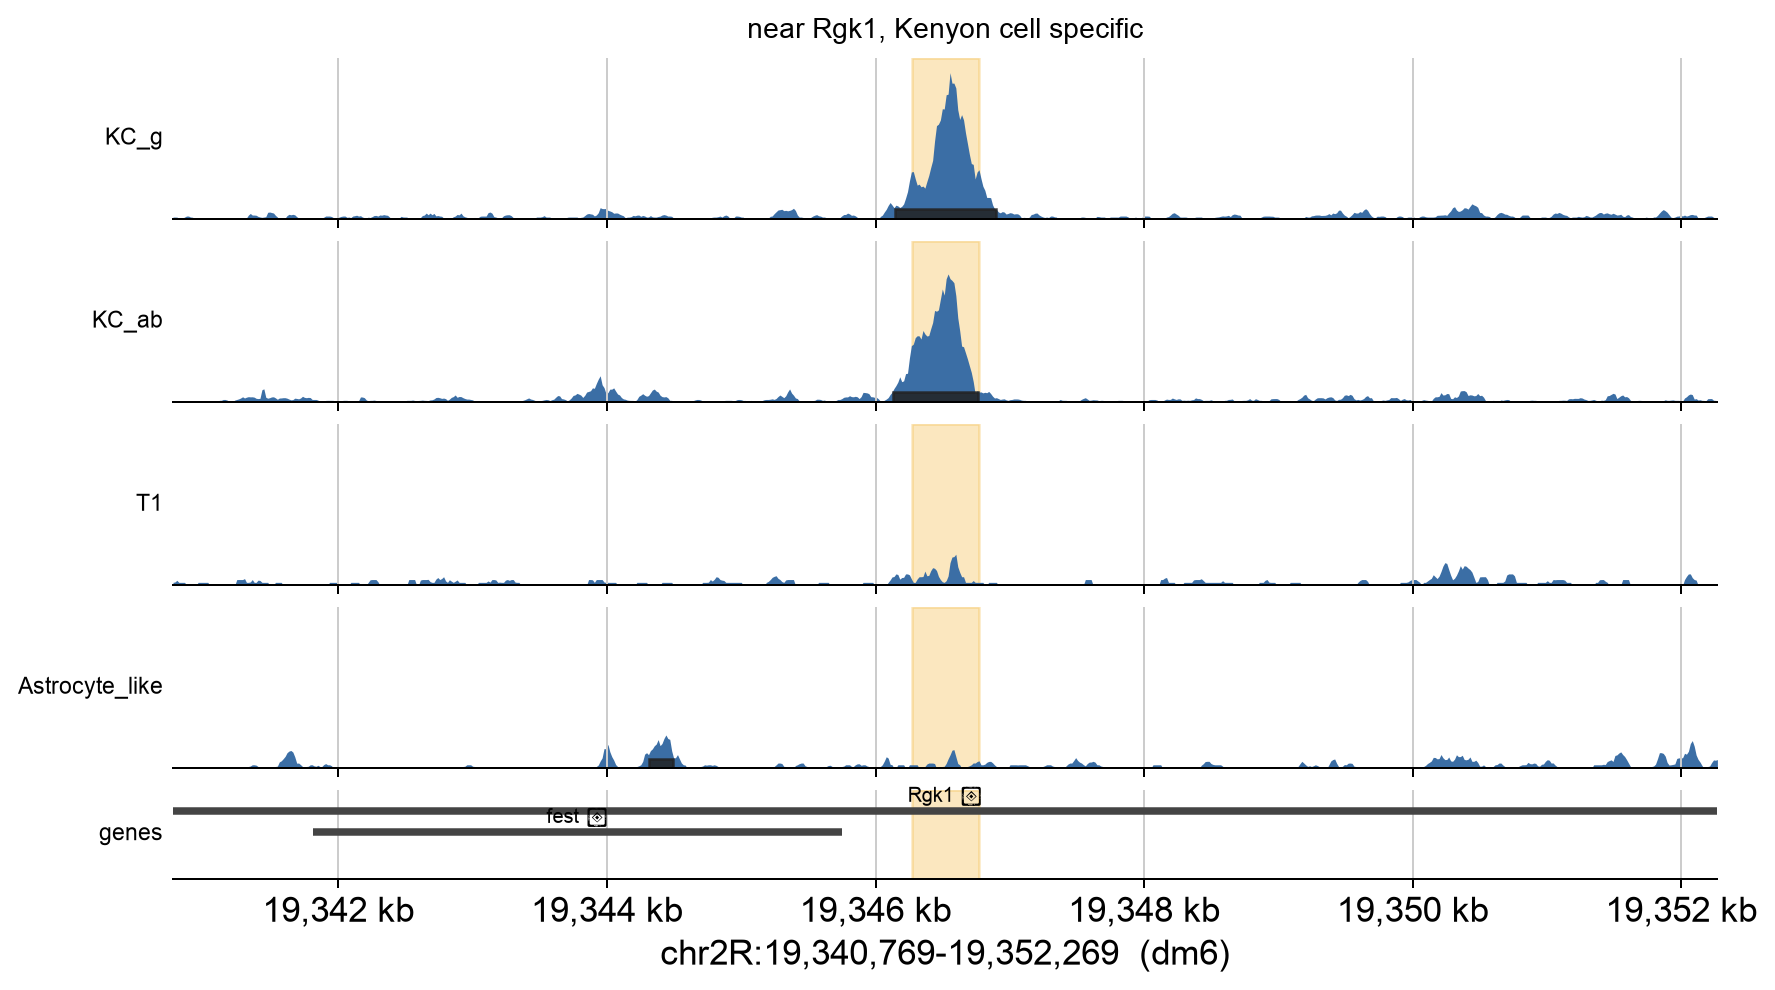

/Users/u0132293/Documents/software/coursework/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


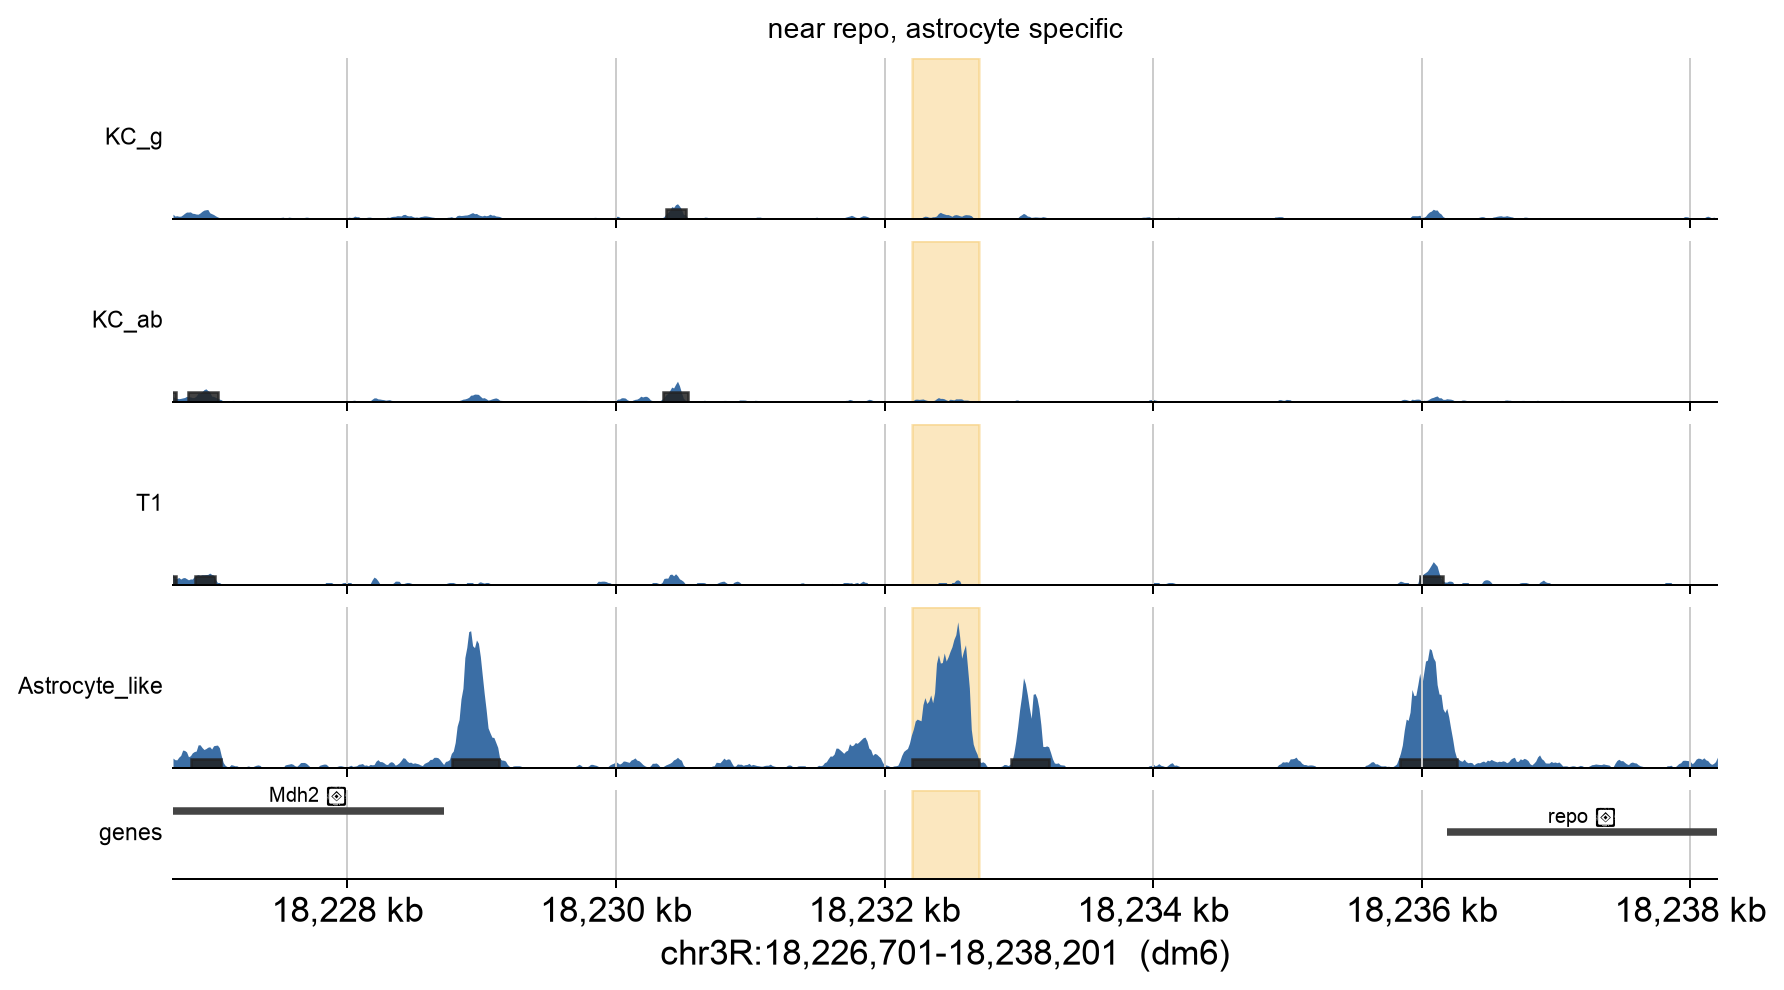

In [32]:
for chrom, start, end, note in MY_REGIONS:
    plot_tracks(bigwig_files, region=(chrom, start - 5_500, end + 5_500),
                peaks=peak_files, highlight=(start, end), title=note)
    plt.show()

## Summary

In this practical you:

1. Downloaded processed single-cell data from the repositories used by the
   original publications, and reduced a 2.5 GB atlas to a working file
2. Used `scanpy` to normalise counts, plot an annotated atlas, and read out the
   expression of individual genes per cell type
3. Ran a differential expression test to find marker genes without assuming
   them, and separated the transcription factors among them
4. Examined a larval dataset containing neural progenitors absent from the adult
   brain, and found that `elav` does not distinguish them from neurons
5. Read bigwig coverage with `pyBigWig` and found that the cell types expressing
   a gene are the cell types with accessible regions near it
6. Identified cell-type-specific regions without prior knowledge of the genes
7. Exported candidate enhancers for sequence-based modelling

The commands used here are the standard ones. `sc.read_h5ad`,
`sc.pp.normalize_total`, `sc.pl.umap`, `sc.tl.rank_genes_groups` and
`sc.get.rank_genes_groups_df` are the core of most published single-cell
analyses, and they work the same way on any dataset you download later.

**For the group project**, record: the cell types compared, one locus where the
difference was unambiguous, the corresponding expression data, and what you infer
the region does.

Practical 6 continues with the regions exported in section 7.